# 4c

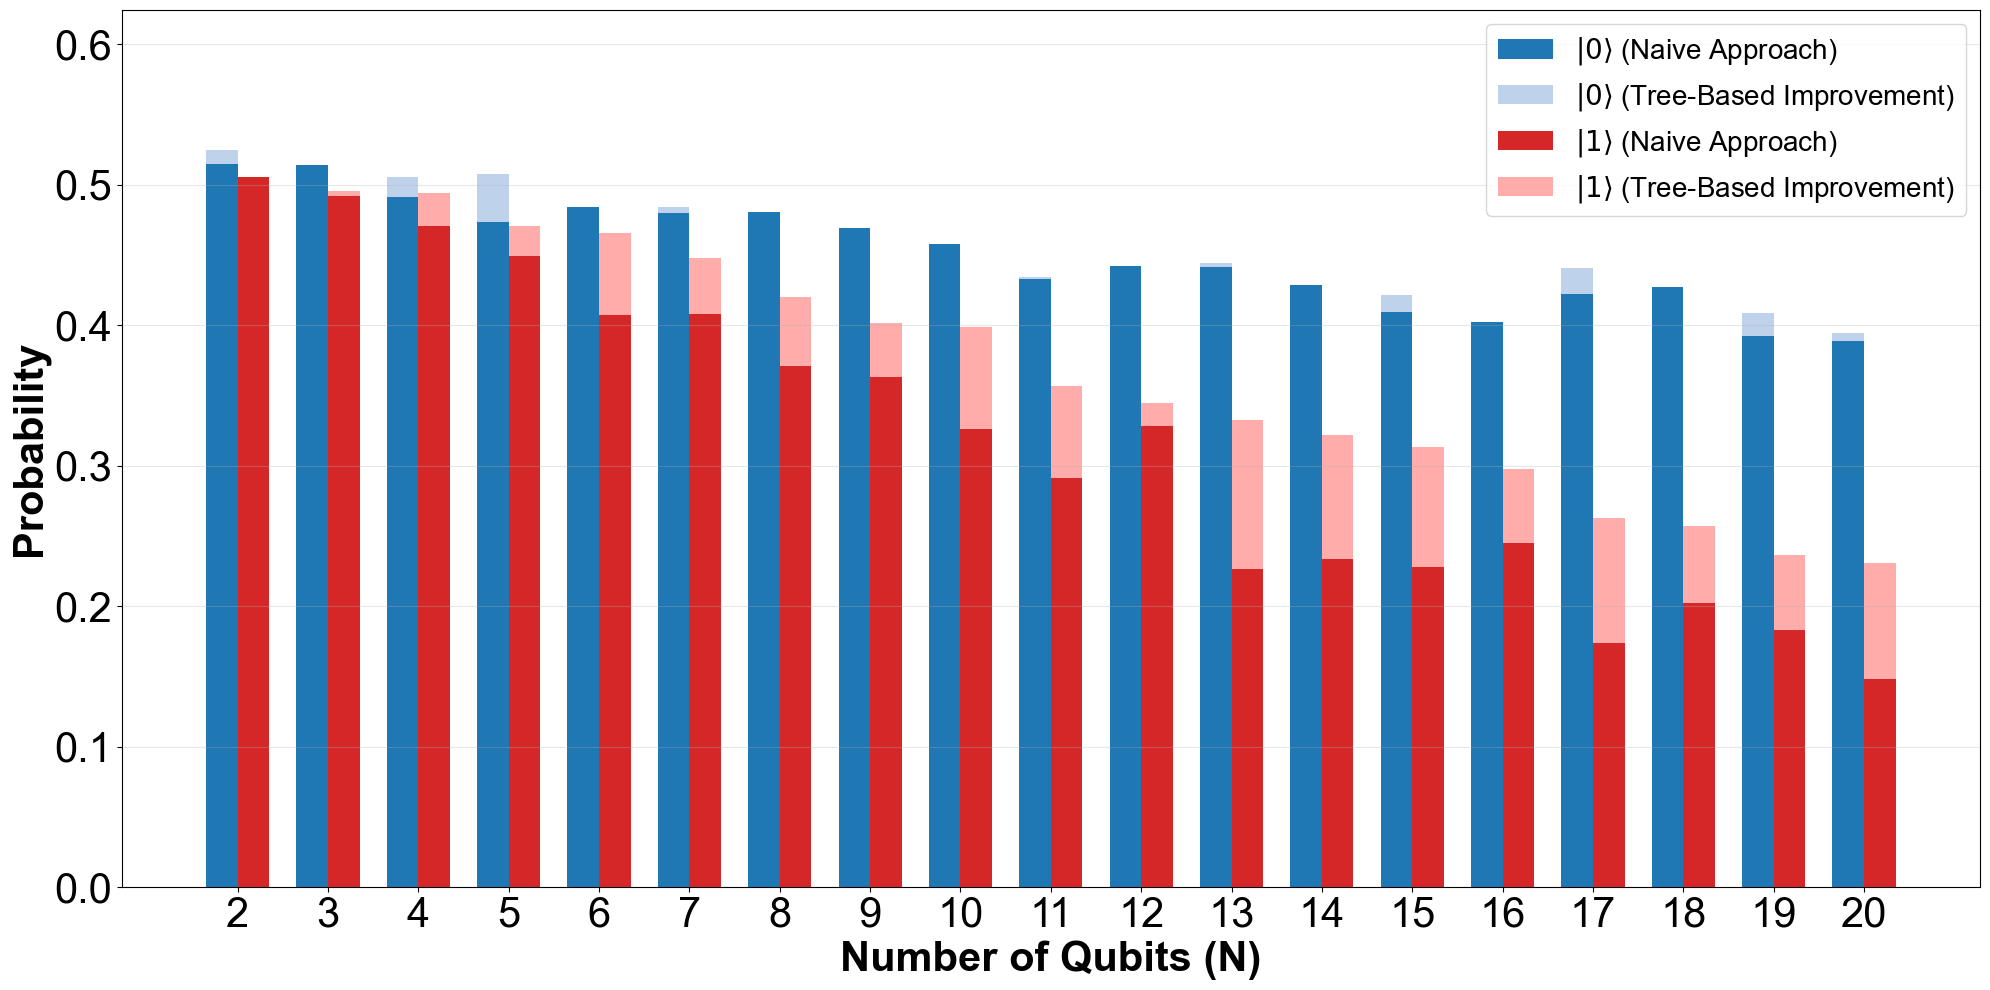

In [1]:
import numpy as np
import matplotlib.pyplot as plt

# ---------------------- 1. 数据定义（替换为你的真实数据） ----------------------
# 比特数：2 ~ 20（共19个）
bit_counts = np.arange(2, 21)
x_labels = [f"{n}" for n in bit_counts]  # X轴标签：N 2, N 3, ..., N 20

# ========== 原始数据（基础部分） ==========
#树状和链状比较
# 全0态原始测量概率（替换为你的真实列表，长度19）
p0_original = np.load("Line_prob0.npy").tolist()
# 全1态原始测量概率（替换为你的真实列表，长度19）
p1_original = np.load("Line_prob1.npy").tolist()
# ========== 排除热噪声后数据（提升后） ==========
# 全0态降噪后概率（需≥原始值，替换为你的真实列表，长度19）
p0_noise_free = np.load("Tree_prob0.npy").tolist()
# 全1态降噪后概率（需≥原始值，替换为你的真实列表，长度19）
p1_noise_free = np.load("Tree_prob1.npy").tolist()


# #后选择和不后选择比较
# p0_original = np.load("C:/Users/WASDH/Desktop/QClub/GHZ通信游戏项目/数据处理/2026-03-09/附录实验/读取/Line_No_select_prob0.npy").tolist()
# # 全1态原始测量概率（替换为你的真实列表，长度19）
# p1_original = np.load("C:/Users/WASDH/Desktop/QClub/GHZ通信游戏项目/数据处理/2026-03-09/附录实验/读取/Line_No_select_prob1.npy").tolist()

# # ========== 排除热噪声后数据（提升后） ==========
# # 全0态降噪后概率（需≥原始值，替换为你的真实列表，长度19）
# p0_noise_free = np.load("C:/Users/WASDH/Desktop/QClub/GHZ通信游戏项目/数据处理/2026-03-09/附录实验/读取/Tree_Post_select_prob0.npy").tolist()
# # 全1态降噪后概率（需≥原始值，替换为你的真实列表，长度19）
# p1_noise_free = np.load("C:/Users/WASDH/Desktop/QClub/GHZ通信游戏项目/数据处理/2026-03-09/附录实验/读取/Tree_Post_select_prob1.npy").tolist()

# 计算提升部分的高度（降噪后 - 原始，确保非负）
p0_improve = np.maximum(0, np.array(p0_noise_free) - np.array(p0_original))
p1_improve = np.maximum(0, np.array(p1_noise_free) - np.array(p1_original))

# ---------------------- 2. 绘图风格与布局配置 ----------------------
plt.rcParams['font.family'] = 'Arial'  # 学术字体
plt.rcParams['axes.unicode_minus'] = False       # 解决负号显示问题

fig, ax = plt.subplots(figsize=(20, 10))  # 画布尺寸匹配参考图
width = 0.35  # 柱状图宽度
x = np.arange(len(bit_counts))  # X轴位置索引

# 配色定义（原有深色 + 同色系淡色）
color_0_original = '#1f77b4'    # 全0原始：深蓝（匹配参考图）
color_0_improve = '#aec7e8'     # 全0提升：淡蓝（同色系浅色调）
color_1_original = '#d62728'    # 全1原始：深红（匹配参考图）
color_1_improve = '#ff9896'     # 全1提升：淡红（同色系浅色调）

# ---------------------- 3. 绘制堆叠柱状图（基础+提升） ----------------------
# ===== 全0态：先画原始深色柱，再堆叠淡色提升柱 =====
# 原始基础柱
rects0_original = ax.bar(
    x - width/2, p0_original, width,
    label=r'$|0\rangle$ (Naive Approach)',
    color=color_0_original
)
# 淡色提升柱（堆叠在原始柱上方）
rects0_improve = ax.bar(
    x - width/2, p0_improve, width,
    bottom=p0_original,  # 从原始柱顶部开始堆叠
    label=r'$|0\rangle$ (Tree-Based Improvement)',
    color=color_0_improve,
    alpha=0.8  # 轻微透明，增强层次感
)

# ===== 全1态：先画原始深色柱，再堆叠淡色提升柱 =====
# 原始基础柱
rects1_original = ax.bar(
    x + width/2, p1_original, width,
    label=r'$|1\rangle$ (Naive Approach)',
    color=color_1_original
)
# 淡色提升柱（堆叠在原始柱上方）
rects1_improve = ax.bar(
    x + width/2, p1_improve, width,
    bottom=p1_original,  # 从原始柱顶部开始堆叠
    label=r'$|1\rangle$ (Tree-Based Improvement)',
    color=color_1_improve,
    alpha=0.8  # 轻微透明，增强层次感
)

# ---------------------- 4. 图表标注与美化 ----------------------
# 标题（补充降噪说明，贴合新数据）
# ax.set_title(
#     'Probability of measuring all 0s and all 1s in a GHZ state (with Noise-Free Optimization)',
#     fontsize=14, pad=15
# )
# 坐标轴标签
ax.set_ylabel('Probability', fontsize=30,fontweight='bold')
ax.set_xlabel("Number of Qubits (N)", fontsize=30, fontweight='bold')
ax.set_xticks(x)
ax.set_xticklabels(x_labels, fontsize=30)
# Y轴范围（适配提升后的数据，略高于最大值）
ax.tick_params(axis='y', labelsize=30)
max_prob = max(np.max(p0_noise_free), np.max(p1_noise_free))
ax.set_ylim(0, max_prob + 0.1)  # 顶部留空，更美观
# 浅灰色网格（仅Y轴，匹配参考图风格）
ax.grid(True, axis='y', linestyle='-', alpha=0.3)
# 图例（调整位置，避免遮挡）
ax.legend(fontsize=20, loc='upper right')

# ---------------------- 5. 显示/保存 ----------------------
plt.tight_layout()  # 自动调整布局，避免标签截断
plt.show()


# 4d

In [2]:
import numpy as np
import matplotlib.pyplot as plt

# ---------------------- 1. 核心配置（替换为你的真实数据） ----------------------
# ========== 🔹 数据集1：排除热噪声（优化后） ==========
# 二维原始数据：19个子列表 → 对应2~20比特，每个子列表是多次测量结果
fidelity_raw_noise_free = np.load("20260309_10_GHZ_fidelity_data_erro_bar.npy").tolist()
# 计算排除热噪声的均值+1σ标准差
fidelity_mean_free = [np.mean(sub) for sub in fidelity_raw_noise_free]
fidelity_std_free = [np.std(sub, ddof=1) for sub in fidelity_raw_noise_free]

# ========== 🔹 数据集2：未排除热噪声（原始） ==========
# 二维原始数据：19个子列表 → 对应2~20比特（替换为你的真实数据）
fidelity_raw_original = np.load("Line_GHZ_Fidelity_erro_bar.npy").tolist()
# 计算未排除热噪声的均值+1σ标准差
fidelity_mean_ori = [np.mean(sub) for sub in fidelity_raw_original]
fidelity_std_ori = [np.std(sub, ddof=1) for sub in fidelity_raw_original]

# 比特数目：2 to 20
bit_counts = np.arange(2, 21)

# 🔹 SVG保存开关
save_svg = False
svg_save_path = "GHZ_fidelity_Tree_and_Line.svg"

# ---------------------- 2. 绘图样式配置（学术级） ----------------------
plt.rcParams["font.family"] = ["Arial", "SimHei"]  # 优先Arial，兼容中文
plt.rcParams["axes.unicode_minus"] = False          # 负号正常显示
plt.rcParams["font.size"] = 11                      # 全局字体大小
plt.rcParams["axes.linewidth"] = 1.2                # 坐标轴线条宽度
plt.rcParams["legend.frameon"] = True               # 图例带边框
plt.rcParams["legend.framealpha"] = 1.0             # 图例边框不透明

# 创建画布
fig, ax = plt.subplots(figsize=(20, 10), dpi=600)

# ---------------------- 3. 绘制两组数据的曲线+标准差区域 ----------------------
# ========== 第一组：排除热噪声（蓝色系） ==========
# 1σ标准差填充区域（浅蓝，半透明）
ax.fill_between(
    bit_counts,
    np.array(fidelity_mean_free) - np.array(fidelity_std_free),
    np.array(fidelity_mean_free) + np.array(fidelity_std_free),
    color='#2E86AB', alpha=0.2, label='Tree-Base Erro Range'
)
# 均值曲线（深蓝，圆形标记）
ax.plot(
    bit_counts, fidelity_mean_free,
    color='#2E86AB', marker='o', markersize=15,
    markerfacecolor='white', markeredgewidth=1.5,
    linewidth=2, linestyle='-', label='Tree-Base (Mean)'
)

# ========== 第二组：未排除热噪声（橙色系） ==========
# 1σ标准差填充区域（浅橙，半透明）
ax.fill_between(
    bit_counts,
    np.array(fidelity_mean_ori) - np.array(fidelity_std_ori),
    np.array(fidelity_mean_ori) + np.array(fidelity_std_ori),
    color='#E17055', alpha=0.2, label='Native Erro Range'
)
# 均值曲线（深橙，方形标记）
ax.plot(
    bit_counts, fidelity_mean_ori,
    color='#E17055', marker='s', markersize=15,
    markerfacecolor='white', markeredgewidth=1.5,
    linewidth=2, linestyle='-', label='Naive Approach (Mean)'
)

# ---------------------- 4. 图表细节优化 ----------------------
# 坐标轴标签
ax.set_xlabel("Number of Qubits (N)", fontsize=30, fontweight='bold')
ax.set_ylabel("Fidelity", fontsize=30, fontweight='bold')

# 标题（补充两组数据说明）
# ax.set_title("GHZ State Fidelity Curve (With/Without Noise-Free Optimization)", 
#              fontsize=30, fontweight='bold', pad=15)

# 自适应Y轴范围（覆盖两组数据）
all_means = fidelity_mean_free + fidelity_mean_ori
y_min = max(0, min(all_means) - 0.1)
y_max = min(1.05, max(all_means) + 0.1)
ax.set_ylim(y_min, y_max)
ax.set_xlim(1.5, 20.5)  # X轴留边

# 刻度优化
ax.set_xticks(bit_counts[::1])  # X刻度：2,4,6...20
ax.set_yticks(np.arange(0, 1.01, 0.1))  # Y刻度：0~1，步长0.1

ax.tick_params(axis='x', labelsize=30)  # X轴数字大小（推荐20-30）
ax.tick_params(axis='y', labelsize=30)  # Y轴数字大小（和X轴统一）

# 网格（仅Y轴，减少干扰）
ax.grid(True, linestyle='--', alpha=0.4, linewidth=0.8, axis='y')
ax.set_axisbelow(True)  # 网格置于底层

# 图例（右上角，分组显示）
ax.legend(loc='upper right', fontsize=20, frameon=True, ncol=1)

# 边框优化
# ax.spines['top'].set_visible(False)
# ax.spines['right'].set_visible(False)
ax.spines['left'].set_color('#333333')
ax.spines['bottom'].set_color('#333333')

# ---------------------- 5. 保存 + 显示 ----------------------
if save_svg:
    plt.savefig(
        svg_save_path,
        format='svg',
        dpi=300,
        bbox_inches='tight'
    )
    print(f"✅ SVG文件已保存至: {svg_save_path}")
else:
    print("ℹ️ SVG保存已关闭（save_svg=False）")

# 自动布局 + 显示
plt.tight_layout()
plt.show()

# 数据验证
print(f"\n📊 数据验证:")
print(f"   - 比特数范围: {bit_counts.min()}~{bit_counts.max()}")
print(f"   - 排除热噪声均值范围: {min(fidelity_mean_free):.3f} ~ {max(fidelity_mean_free):.3f}")
print(f"   - 未排除热噪声均值范围: {min(fidelity_mean_ori):.3f} ~ {max(fidelity_mean_ori):.3f}")

ℹ️ SVG保存已关闭（save_svg=False）



📊 数据验证:
   - 比特数范围: 2~20
   - 排除热噪声均值范围: 0.565 ~ 1.011
   - 未排除热噪声均值范围: 0.461 ~ 0.988


In [ ]:
table_data = {
    'N':              [1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20],
    'Before_F0→0':    [0.9697, 0.9628, 0.9603, 0.9653, 0.9573, 0.9564, 0.9643, 0.9490, 0.9659, 0.9634,
                       0.9623, 0.9446, 0.9592, 0.9607, 0.9717, 0.9759, 0.9463, 0.9514, 0.9572, 0.9521],
    'Before_F1→1':    [0.9637, 0.9528, 0.9543, 0.9553, 0.9273, 0.9464, 0.9503, 0.9470, 0.9599, 0.9534,
                       0.9523, 0.9186, 0.9572, 0.9507, 0.9617, 0.9659, 0.9403, 0.9374, 0.9472, 0.9581],
    'After_F0→0':     [0.9917, 0.9942, 0.9968, 0.9907, 0.9804, 0.9867, 0.9853, 0.9870, 0.9977, 0.9965,
                       0.9960, 0.9706, 0.9893, 0.9902, 0.9933, 0.9792, 0.9875, 0.9872, 0.9821, 0.9918],
    'After_F1→1':     [0.9877, 0.9912, 0.9928, 0.9877, 0.9554, 0.9827, 0.9823, 0.9830, 0.9937, 0.9935,
                       0.9920, 0.9702, 0.9853, 0.9872, 0.9893, 0.9752, 0.9835, 0.9842, 0.9781, 0.9828],
}
np.save('all_qubits_read_fidelity.',table_data)